In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv('train.csv')

# Sanity checks
print(df.shape)
print(df.dtypes)
df.head()

(80000, 41)
runner_id                          object
age                                 int64
gender                             object
running_experience_months           int64
previous_marathon_count             int64
training_program                   object
motivation_level                    int64
personal_best_minutes             float64
weekly_mileage_km                 float64
weekly_mileage_miles              float64
runs_per_week                       int64
long_run_distance_km              float64
speed_work_sessions_per_week        int64
rest_days_per_week                  int64
training_adherence_pct              int64
consecutive_weeks_no_miss           int64
cross_training_hours_per_week     float64
resting_heart_rate_bpm              int64
vo2_max                           float64
bmi                               float64
recovery_score                    float64
sleep_hours_avg                   float64
injury_count                        int64
injury_severity       

,runner_id,age,gender,running_experience_months,previous_marathon_count,training_program,motivation_level,personal_best_minutes,weekly_mileage_km,weekly_mileage_miles,...,run_club_attendance_rate,warmup_adherence_pct,stretching_adherence_pct,marathon_date,marathon_weather,course_difficulty,target_finish_time_minutes,actual_finish_time_minutes,mental_preparation_score,medal_outcome
0,R009432,25,Male,48,0,Intermediate,4,NaN,20.0,12.4,...,0,70,29,2025-02-02,Hot,Mixed,254,297.0,5,0
1,R077741,43,Female,151,2,Advanced,1,196.0,20.0,12.4,...,0,94,0,2024-02-11,Sunny,Mixed,201,231.0,7,1
2,R034376,32,Female,82,3,Advanced,6,211.0,23.1,14.4,...,54,47,39,2025-03-27,Rainy,Flat,204,234.0,9,1
3,R020754,57,Male,6,0,Beginner,8,NaN,27.3,17.0,...,63,77,45,2024-04-16,Sunny,Hilly,258,276.0,3,3
4,R001301,54,Female,11,0,Beginner,3,NaN,20.0,12.4,...,20,64,40,2025-10-21,Cloudy,Mixed,245,296.0,8,0


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 41 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   runner_id                       80000 non-null  object 
 1   age                             80000 non-null  int64  
 2   gender                          80000 non-null  object 
 3   running_experience_months       80000 non-null  int64  
 4   previous_marathon_count         80000 non-null  int64  
 5   training_program                80000 non-null  object 
 6   motivation_level                80000 non-null  int64  
 7   personal_best_minutes           69255 non-null  float64
 8   weekly_mileage_km               80000 non-null  float64
 9   weekly_mileage_miles            80000 non-null  float64
 10  runs_per_week                   80000 non-null  int64  
 11  long_run_distance_km            80000 non-null  float64
 12  speed_work_sessions_per_week    

runner_id                             0
age                                   0
gender                                0
running_experience_months             0
previous_marathon_count               0
training_program                      0
motivation_level                      0
personal_best_minutes             10745
weekly_mileage_km                     0
weekly_mileage_miles                  0
runs_per_week                         0
long_run_distance_km                  0
speed_work_sessions_per_week          0
rest_days_per_week                    0
training_adherence_pct                0
consecutive_weeks_no_miss             0
cross_training_hours_per_week      7983
resting_heart_rate_bpm                0
vo2_max                            9611
bmi                                   0
recovery_score                        0
sleep_hours_avg                    3942
injury_count                          0
injury_severity                   47350
nutrition_score                    6402


<Axes: xlabel='target_finish_time_minutes', ylabel='Count'>

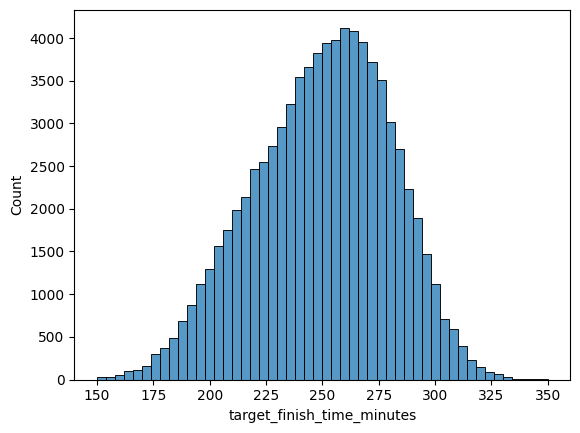

In [4]:
# Target distribution
sns.histplot(df['target_finish_time_minutes'], bins=50)

<Axes: >

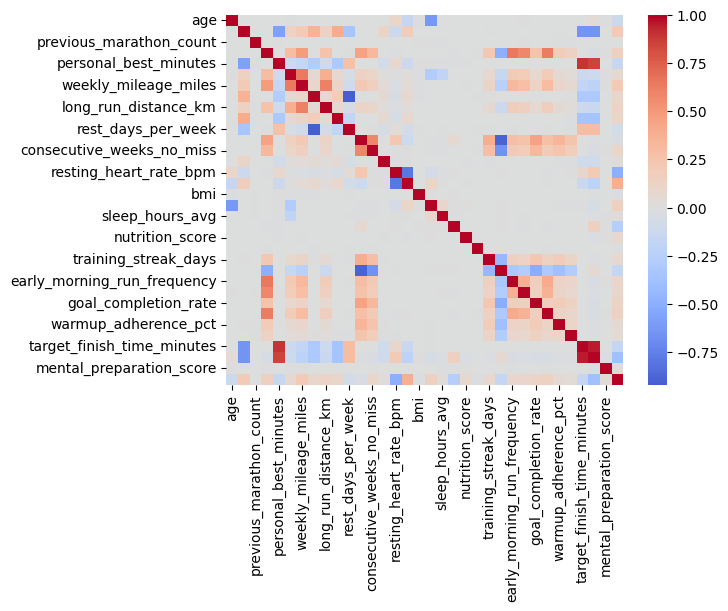

In [5]:
# Correlation heatmap
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', center=0)

In [6]:
df.columns.tolist()

['runner_id',
 'age',
 'gender',
 'running_experience_months',
 'previous_marathon_count',
 'training_program',
 'motivation_level',
 'personal_best_minutes',
 'weekly_mileage_km',
 'weekly_mileage_miles',
 'runs_per_week',
 'long_run_distance_km',
 'speed_work_sessions_per_week',
 'rest_days_per_week',
 'training_adherence_pct',
 'consecutive_weeks_no_miss',
 'cross_training_hours_per_week',
 'resting_heart_rate_bpm',
 'vo2_max',
 'bmi',
 'recovery_score',
 'sleep_hours_avg',
 'injury_count',
 'injury_severity',
 'nutrition_score',
 'hydration_consistency',
 'training_streak_days',
 'missed_workout_pct',
 'early_morning_run_frequency',
 'weather_condition_training_pct',
 'goal_completion_rate',
 'run_club_attendance_rate',
 'warmup_adherence_pct',
 'stretching_adherence_pct',
 'marathon_date',
 'marathon_weather',
 'course_difficulty',
 'target_finish_time_minutes',
 'actual_finish_time_minutes',
 'mental_preparation_score',
 'medal_outcome']

In [7]:
df_35_44 = df[(df['age'] >= 35) & (df['age'] <= 44)].copy()
print(df_35_44.shape)

(16709, 41)


In [8]:
# Categorical features
df_35_44.select_dtypes(include='object').columns.tolist()

['runner_id',
 'gender',
 'training_program',
 'injury_severity',
 'marathon_date',
 'marathon_weather',
 'course_difficulty']

In [9]:
# Label encode
cat_cols = df_35_44.select_dtypes(include='object').columns.tolist()

le = LabelEncoder()
for col in cat_cols:
    df_35_44[col] = le.fit_transform(df_35_44[col].astype(str))

In [10]:
corr_target = df_35_44.corr(numeric_only=True)['target_finish_time_minutes'].sort_values()
print(corr_target)

running_experience_months        -0.658716
speed_work_sessions_per_week     -0.347104
runs_per_week                    -0.317772
weekly_mileage_miles             -0.171667
medal_outcome                    -0.169940
vo2_max                          -0.133194
weekly_mileage_km                -0.113727
cross_training_hours_per_week    -0.110036
long_run_distance_km             -0.101960
missed_workout_pct               -0.012995
age                              -0.007823
gender                           -0.004826
injury_count                     -0.004264
marathon_weather                 -0.003552
weather_condition_training_pct   -0.003257
injury_severity                  -0.002852
previous_marathon_count          -0.001351
run_club_attendance_rate         -0.000213
bmi                              -0.000120
training_streak_days             -0.000118
hydration_consistency             0.000894
mental_preparation_score          0.000938
runner_id                         0.001190
early_morni

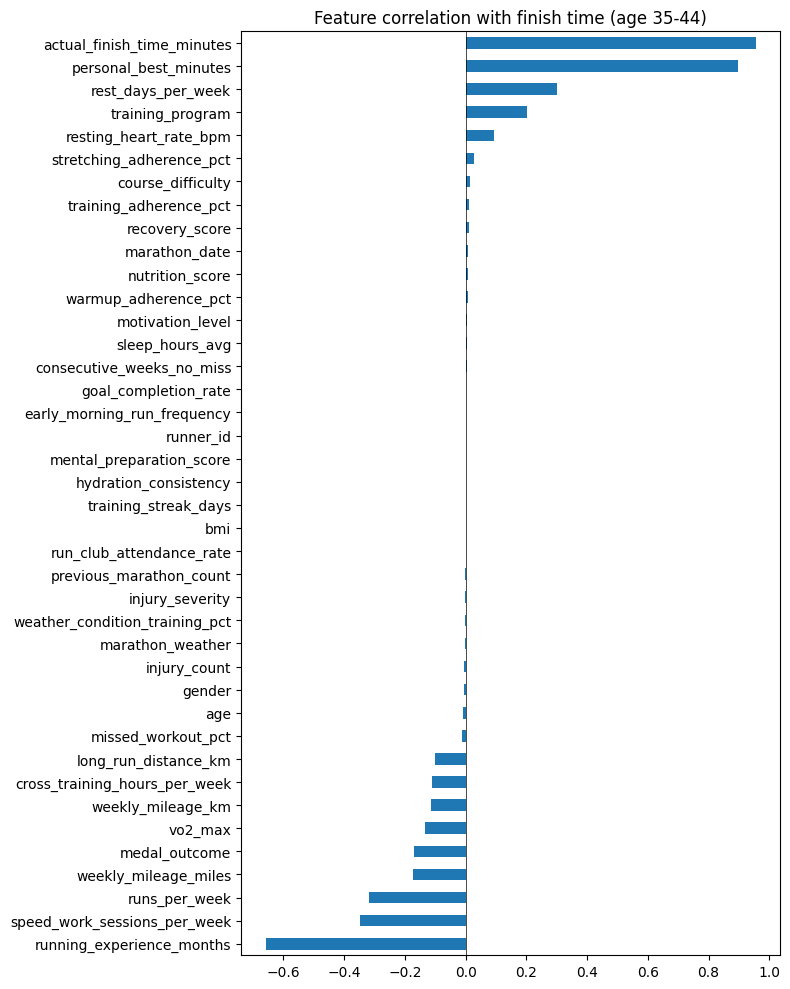

In [11]:
corr_target.drop('target_finish_time_minutes').plot(kind='barh', figsize=(8, 10))
plt.axvline(0, color='black', linewidth=0.5)
plt.title('Feature correlation with finish time (age 35-44)')
plt.tight_layout()